# PGD Adversarial Attacks

## Projected Gradient Descent - Implementazione e Valutazione

Questo notebook implementa attacchi PGD da zero e valuta l'accuratezza del modello ResNet18 addestrato

## 1. Setup e Import

In [17]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT = Path('..')
BATCH_SIZE = 32
IMG_SIZE = 224
N_CLASSES = 5


model = models.resnet18(pretrained=True)
model.fc = nn.Linear(in_features=512, out_features=N_CLASSES)
model = model.to(device)

model_path = ROOT / "models" / "best_resnet18.pt"
model.load_state_dict(torch.load(model_path))
model.eval()


NORMALIZE = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

TRANSFORMS = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

dataset_path = ROOT / "data" / "fruits-classification-stratified"

train_dataset = ImageFolder(root=dataset_path / 'train', transform=TRANSFORMS)
val_dataset = ImageFolder(root=dataset_path / 'valid', transform=TRANSFORMS)
test_dataset = ImageFolder(root=dataset_path / 'test', transform=TRANSFORMS)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

class_names = test_dataset.classes

results_path = ROOT / "results"
results_path.mkdir(exist_ok=True)

print(f"\nSetup e import completati")


Setup e import completati


/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 2. Implementazione PGD (da zero)

PGD (Projected Gradient Descent) è una versione iterativa di FGSM:

1. Parte da un intorno di epsilon 
2. Ad ogni iterazione applica FGSM con step size alpha
3. Si assicura che la perturbazione totale sia all'interno del range
4. Ripete le operazioni per n iterazioni

In [18]:
def pgd_attack(model, images, labels, epsilon, alpha, num_steps, loss_fn):
    """
    Esegue un attacco PGD su un batch di immagini

    Args:
        model: il modello target da ingannare
        images: batch di immagini
        labels: label vere per il batch
        epsilon: raggio massimo della perturbazione (norma inf)
        alpha: step size per ogni iterazione
        num_steps: numero di iterazioni dell'attacco
        loss_fn: funzione di loss (CrossEntropyLoss)

    Returns:
        adv_images: immagini perturbate
        perturbation: il rumore aggiunto
    """

    adv_images = images.clone().detach()

    # partenza casuale
    adv_images = adv_images + torch.empty_like(adv_images).uniform_(-epsilon, epsilon)
    adv_images = torch.clamp(adv_images, 0, 1).detach()

    for _ in range(num_steps):

        adv_images.requires_grad = True

        outputs = model(NORMALIZE(adv_images))
        loss = loss_fn(outputs, labels)

        # pulisce i gradienti precedenti
        model.zero_grad()

        loss.backward()

        # estrae il segno dei gradienti (solo direzione, non ampiezza)
        gradient_sign = adv_images.grad.sign()

        # singola perturbazione (FGSM)
        adv_images = adv_images.detach() + alpha * gradient_sign

        # deve stare all'interno di epsilon
        perturbation = torch.clamp(adv_images - images, -epsilon, epsilon)

        adv_images = torch.clamp(images + perturbation, 0, 1).detach()

    perturbation = adv_images - images

    return adv_images, perturbation.detach()


print("Funzione PGD implementata")

Funzione PGD implementata


## 3. Test PGD con Epsilon diversi

Testare l'attacco PGD su diversi valori di epsilon per capire quando il modello inizia a sbagliare.

Metriche:
- **Accuracy**: % di immagini classificate correttamente dal modello (senza attacco)
- **Attack Success Rate (ASR)**: % di immagini dove l'attacco ha ingannato il modello
- **Time**: tempo totale per applicare l'attacco al test set

Problema: usare gli stessi epsilon di FGSM

In [19]:
epsilon_values = [0.0005, 0.001, 0.003, 0.005, 0.01]
epsilon_to_visualize = [0.0005, 0.003, 0.01]

num_steps = 10 

loss_fn = nn.CrossEntropyLoss()
pgd_results = {}

examples_store = {eps: {'success': [], 'failure': []} for eps in epsilon_to_visualize}

for epsilon in epsilon_values:
    alpha = epsilon / 4  # step size standard 
    print(f"\nTest epsilon = {epsilon}, alpha = {alpha:.4f}, num_steps = {num_steps}")

    correct_original = 0
    correct_adv = 0
    attack_success_count = 0
    total_samples = 0

    start_time = time.time()

    model.eval()

    for images, labels in tqdm(test_loader, desc=f"epsilon={epsilon}"):
        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            outputs_original = model(NORMALIZE(images))
            preds_original = torch.argmax(outputs_original, dim=1)
            correct_original += (preds_original == labels).sum().item()

        # ATTACCO PGD
        adv_images, perturbation = pgd_attack(
            model,
            images.clone().detach(),
            labels,
            epsilon,
            alpha,
            num_steps,
            loss_fn,
        )

        with torch.no_grad():
            outputs_adv = model(NORMALIZE(adv_images))
            preds_adv = torch.argmax(outputs_adv, dim=1)
            correct_adv += (preds_adv == labels).sum().item()

        success = (preds_original == labels) & (preds_adv != labels)
        attack_success_count += success.sum().item()

        total_samples += labels.size(0)

        if epsilon in epsilon_to_visualize:
           for i in range(images.size(0)):
            pred_orig = preds_original[i].item()
            pred_adv = preds_adv[i].item()
            true_label = labels[i].item()

            attack_success = pred_orig == true_label and pred_adv != true_label
            attack_failure = pred_orig == true_label and pred_adv == true_label

            example = {
                'image': images[i:i+1].detach().cpu().clone(),
                'adv_image': adv_images[i:i+1].detach().cpu().clone(),
                'perturbation': perturbation[i:i+1].detach().cpu().clone(),
                'pred_original': pred_orig,
                'pred_adv': pred_adv,
                'true_label': true_label,
            }

            if attack_success: examples_store[epsilon]['success'].append(example)

            elif attack_failure: examples_store[epsilon]['failure'].append(example)

    # metriche
    accuracy = correct_original / total_samples
    accuracy_adv = correct_adv / total_samples
    accuracy_drop = accuracy - accuracy_adv
    asr = attack_success_count / correct_original
    elapsed_time = time.time() - start_time

    pgd_results[epsilon] = {
        'accuracy': accuracy,
        'accuracy_adv': accuracy_adv,
        'accuracy_drop': accuracy_drop,
        'asr': asr,
        'time': elapsed_time,
    }

    print(f"  Accuracy (clean): {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Accuracy (adversarial): {accuracy_adv:.4f} ({accuracy_adv*100:.2f}%)")
    print(f"  Accuracy Drop: {accuracy_drop:.4f} ({accuracy_drop*100:.2f}%)")
    print(f"  Attack Success Rate: {asr:.4f} ({asr*100:.2f}%)")
    print(f"  Tempo: {elapsed_time:.2f}s")

print("\nTest completato per tutti gli epsilon")


Test epsilon = 0.0005, alpha = 0.0001, num_steps = 10


epsilon=0.0005:   0%|          | 0/32 [00:00<?, ?it/s]

epsilon=0.0005: 100%|██████████| 32/32 [00:04<00:00,  6.63it/s]


  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.7866 (78.66%)
  Accuracy Drop: 0.1253 (12.53%)
  Attack Success Rate: 0.1374 (13.74%)
  Tempo: 4.83s

Test epsilon = 0.001, alpha = 0.0003, num_steps = 10


epsilon=0.001: 100%|██████████| 32/32 [00:03<00:00,  8.81it/s]


...

  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.0962 (9.62%)
  Accuracy Drop: 0.8156 (81.56%)
  Attack Success Rate: 0.8945 (89.45%)
  Tempo: 4.79s

Test epsilon = 0.005, alpha = 0.0013, num_steps = 10


epsilon=0.005: 100%|██████████| 32/32 [00:03<00:00,  8.79it/s]


  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.0120 (1.20%)
  Accuracy Drop: 0.8998 (89.98%)
  Attack Success Rate: 0.9868 (98.68%)
  Tempo: 3.64s

Test epsilon = 0.01, alpha = 0.0025, num_steps = 10


epsilon=0.01: 100%|██████████| 32/32 [00:04<00:00,  6.65it/s]

  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.0000 (0.00%)
  Accuracy Drop: 0.9118 (91.18%)
  Attack Success Rate: 1.0000 (100.00%)
  Tempo: 4.81s

Test completato per tutti gli epsilon


## 4. Plot delle immagini perturbate

Per ogni epsilon verranno mostrate:
- immagini originali
- perturbazioni (rumore aggiunto)
- immagini perturbate (originale + rumore)

Questo aiuta a capire quanto l'attacco sia "visibile" all'occhio umano e come confonde il modello.


Epsilon = 0.0005


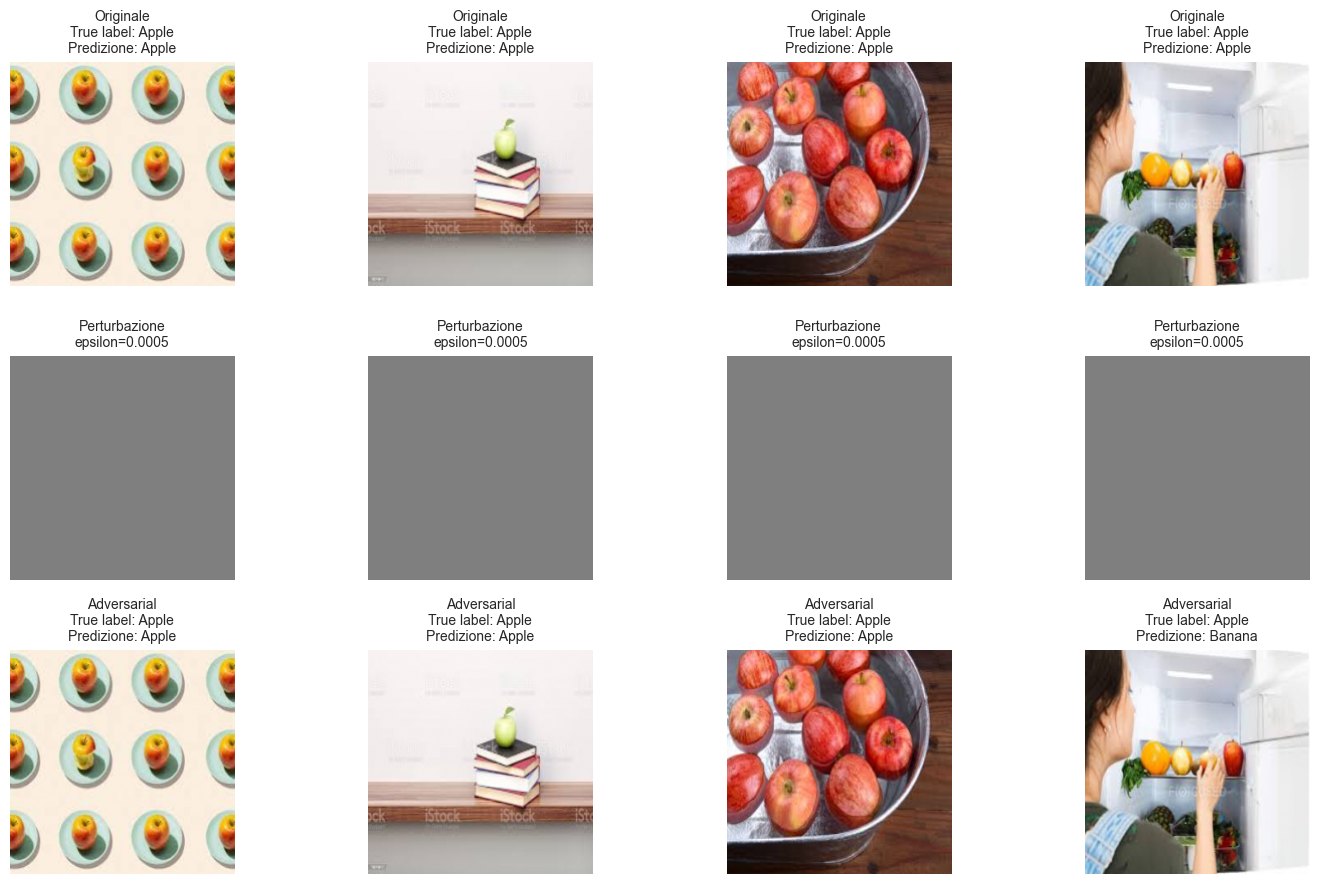


Epsilon = 0.003


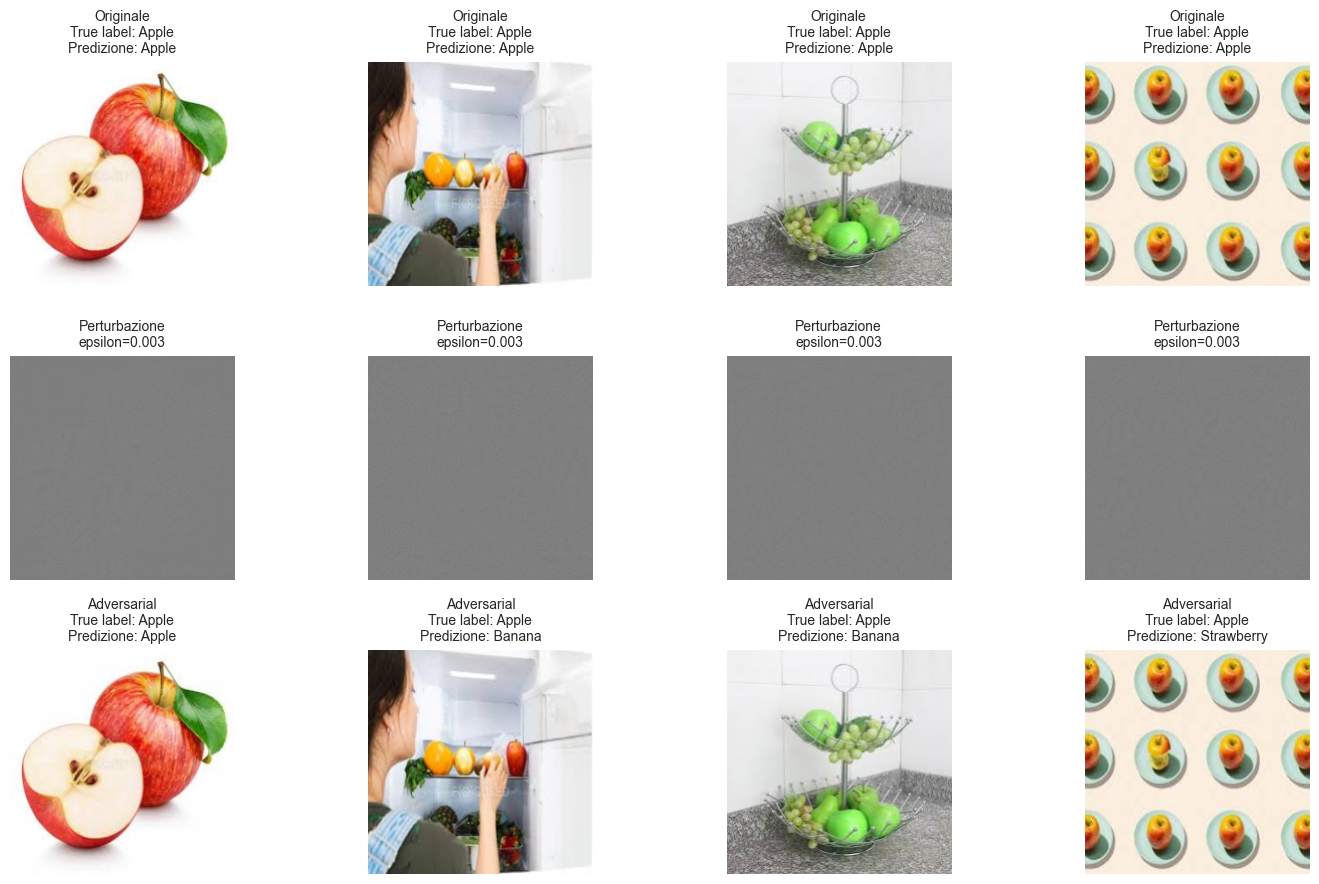


Epsilon = 0.01


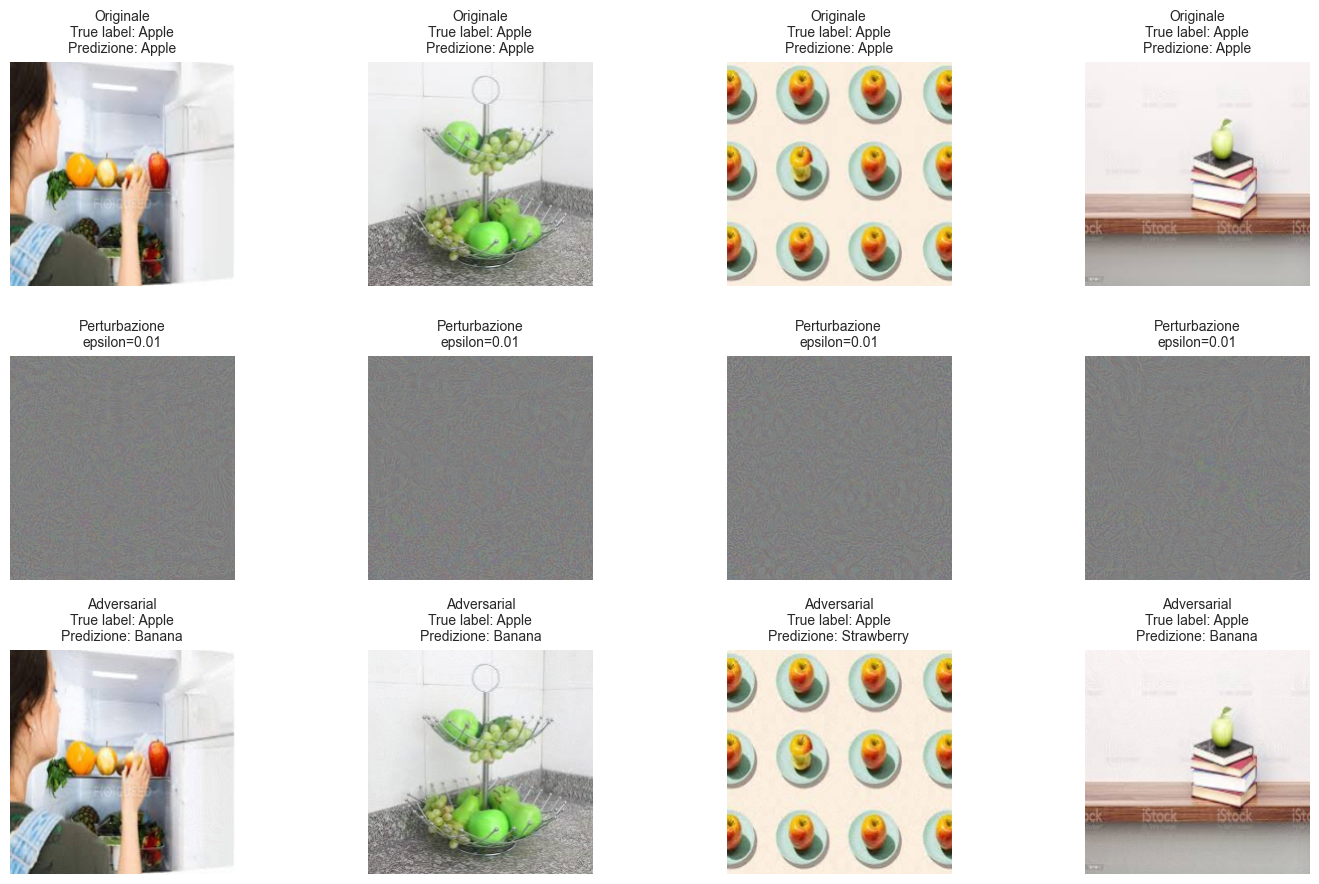

In [20]:
# eps=0.0005: 3 classificate bene + 1 classificata male
# eps=0.003: 1 classificate bene + 3 classificate male
# eps=0.01: 0 classificata bene + 4 classificate male
# scelti arbitrariamente

plot_config = {
    0.0005: {'correct': 3, 'wrong': 1},
    0.003: {'correct': 1, 'wrong': 3},
    0.01: {'correct': 0, 'wrong': 4}, # perche non ce ne sono
}

for epsilon in epsilon_to_visualize:
    selected_examples = (
        examples_store[epsilon]['failure'][:plot_config[epsilon]['correct']] +
        examples_store[epsilon]['success'][:plot_config[epsilon]['wrong']]
    )

    fig, axes = plt.subplots(3, 4, figsize=(15, 9))

    for img_idx in range(4):
        example = selected_examples[img_idx]

        img_original = example['image'][0].numpy()
        img_original = np.transpose(img_original, (1, 2, 0))
        img_original = np.clip(img_original, 0, 1)

        perturbation = example['perturbation'][0].numpy()
        perturbation = np.transpose(perturbation, (1, 2, 0))
        perturbation = perturbation * 3 + 0.5  
        perturbation = np.clip(perturbation, 0, 1)

        img_adv = example['adv_image'][0].numpy()
        img_adv = np.transpose(img_adv, (1, 2, 0))
        img_adv = np.clip(img_adv, 0, 1)

        true_label = example['true_label']
        pred_original = example['pred_original']
        pred_adv = example['pred_adv']

        # immagini originali
        ax = axes[0, img_idx]
        ax.imshow(img_original)
        ax.set_title(f"Originale\nTrue label: {class_names[true_label]}\nPredizione: {class_names[pred_original]}", fontsize=10)
        ax.axis('off')

        # perturbazioni
        ax = axes[1, img_idx]
        ax.imshow(perturbation)
        ax.set_title(f"Perturbazione\nepsilon={epsilon}", fontsize=10)
        ax.axis('off')

        # immagini adversarial
        ax = axes[2, img_idx]
        ax.imshow(img_adv)
        ax.set_title(f"Adversarial\nTrue label: {class_names[true_label]}\nPredizione: {class_names[pred_adv]}", fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(results_path / f"pgd_attack_{epsilon}.png", dpi=120, bbox_inches='tight')
    print(f"\nEpsilon = {epsilon}")
    plt.show()

## 5. Plot delle Metriche

Generazione di grafici riguardanti le metriche:
- Accuracy su immagini originali vs immagini perturbate
- Calo di accuracy (accuracy drop)
- Attack Success Rate (ASR)
- Tempo per applicare l'attacco al test set

/tmp/ipykernel_2260486/2095513670.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eps_labels, y=acc_drop, palette='Reds', ax=ax)
/tmp/ipykernel_2260486/2095513670.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eps_labels, y=asr, palette='Blues', ax=ax)
/tmp/ipykernel_2260486/2095513670.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eps_labels, y=times, palette='Greens', ax=ax)


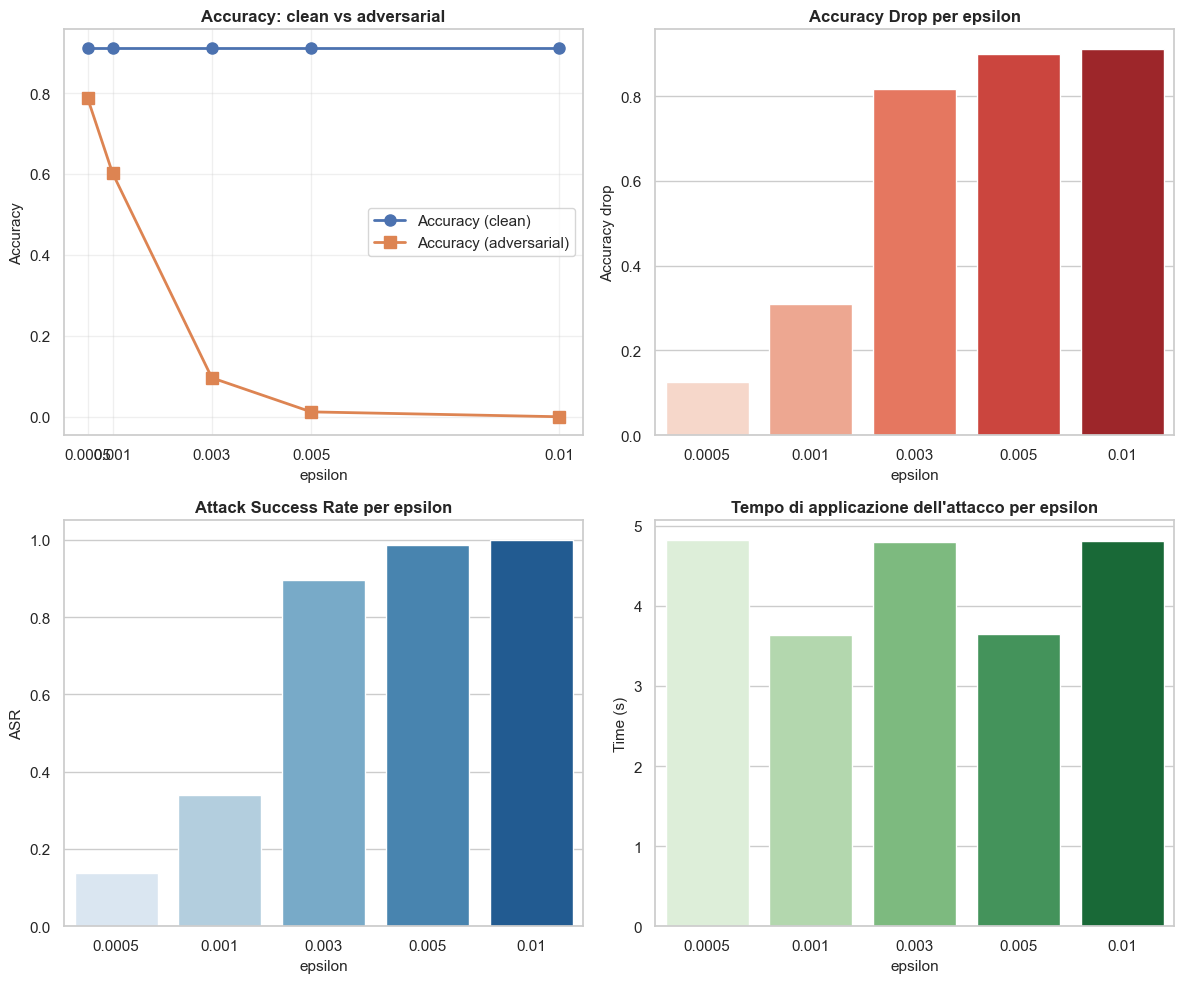

In [21]:
eps = epsilon_values
acc = [pgd_results[e]['accuracy'] for e in eps]
acc_adv = [pgd_results[e]['accuracy_adv'] for e in eps]
acc_drop = [pgd_results[e]['accuracy_drop'] for e in eps]
asr = [pgd_results[e]['asr'] for e in eps]
times = [pgd_results[e]['time'] for e in eps]

eps_labels = [str(e) for e in eps]

sns.set(style='whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# accuracy: clean vs adversarial
ax = axes[0, 0]
ax.plot(eps, acc, marker='o', label='Accuracy (clean)', linewidth=2, markersize=8)
ax.plot(eps, acc_adv, marker='s', label='Accuracy (adversarial)', linewidth=2, markersize=8)
ax.set_xlabel('epsilon', fontsize=11)
ax.set_xticks(eps)
ax.set_xticklabels(eps_labels)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Accuracy: clean vs adversarial', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# accuracy drop
ax = axes[0, 1]
sns.barplot(x=eps_labels, y=acc_drop, palette='Reds', ax=ax)
ax.set_xlabel('epsilon', fontsize=11)
ax.set_ylabel('Accuracy drop', fontsize=11)
ax.set_title('Accuracy Drop per epsilon', fontsize=12, fontweight='bold')

# Attack Success Rate (ASR)
ax = axes[1, 0]
sns.barplot(x=eps_labels, y=asr, palette='Blues', ax=ax)
ax.set_xlabel('epsilon', fontsize=11)
ax.set_ylabel('ASR', fontsize=11)
ax.set_title('Attack Success Rate per epsilon', fontsize=12, fontweight='bold')

# tempo
ax = axes[1, 1]
sns.barplot(x=eps_labels, y=times, palette='Greens', ax=ax)
ax.set_xlabel('epsilon', fontsize=11)
ax.set_ylabel('Time (s)', fontsize=11)
ax.set_title("Tempo di applicazione dell'attacco per epsilon", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(results_path / 'PGD_metrics_summary.png', dpi=120, bbox_inches='tight')
plt.show()

# tabella riassuntiva
summary_df = pd.DataFrame({
    'epsilon': eps,
    'accuracy': acc,
    'accuracy_adv': acc_adv,
    'accuracy_drop': acc_drop,
    'asr': asr,
    'time_s': times,
})
summary_df.to_csv(results_path / 'PGD_metrics_summary.csv', index=False)


## 6. Adversarial Training

Addestramento di un nuovo modello con dati misti: 50% immagini originali + 50% immagini perturbate (PGD con epsilon=0.1, alpha=0.01, num_steps=10).

Durante il training si usano meno iterazioni rispetto alla valutazione dell'attacco per ridurre i tempi di addestramento.

In [22]:
epsilon_adv_training = 0.001
alpha_adv_training = 0.00025
num_steps_adv_training = 10 

pgd_model = models.resnet18(pretrained=True)
pgd_model.fc = nn.Linear(in_features=512, out_features=N_CLASSES)
pgd_model = pgd_model.to(device)

model_path = ROOT / "models" / "best_resnet18.pt"
pgd_model.load_state_dict(torch.load(model_path))

adv_loss_fn = nn.CrossEntropyLoss()
adv_optimizer = torch.optim.Adam(pgd_model.parameters(), lr=0.0001)

num_epochs = 50
patience = 20
best_val_loss = float('inf')
patience_counter = 0

model_save_path = ROOT / "models" / "best_pgd_eps_001.pt"
model_save_path.parent.mkdir(parents=True, exist_ok=True)

adv_train_history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

for epoch in range(num_epochs):
    pgd_model.train()

    epoch_loss = 0
    correct_train = 0
    total_train = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)
        labels = labels.to(device)

        batch_size_half = images.size(0) // 2

        clean_images = images[:batch_size_half]

        adv_images, perturbation = pgd_attack(
            pgd_model,
            images[batch_size_half:].clone().detach(),
            labels[batch_size_half:],
            epsilon_adv_training,
            alpha_adv_training,
            num_steps_adv_training,
            adv_loss_fn
        )

        mixed_images = torch.cat([clean_images, adv_images], dim=0)
        mixed_labels = labels

        adv_optimizer.zero_grad()
        outputs = pgd_model(NORMALIZE(mixed_images))
        loss = adv_loss_fn(outputs, mixed_labels)
        loss.backward()
        adv_optimizer.step()

        epoch_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_loss = epoch_loss / len(train_loader)
    train_acc = correct_train / total_train

    pgd_model.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = pgd_model(NORMALIZE(images))
            loss = adv_loss_fn(outputs, labels)

            val_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_loss = val_loss / len(val_loader)
    val_acc = correct_val / total_val

    adv_train_history['train_loss'].append(train_loss)
    adv_train_history['train_acc'].append(train_acc)
    adv_train_history['val_loss'].append(val_loss)
    adv_train_history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(pgd_model.state_dict(), model_save_path)
        print("Nuovo migliore modello salvato")
    else:
        patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

pgd_model.load_state_dict(torch.load(model_save_path))

print("Adversarial training completato")
print(f"Miglior validation loss: {best_val_loss:.4f}")

/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/50:   8%|▊         | 19/250 [00:01<00:15, 15.11it/s]

Epoch 1/50: 100%|██████████| 250/250 [00:16<00:00, 15.28it/s]


Epoch 1: Train Loss=0.3114, Train Acc=0.8876, Val Loss=0.2853, Val Acc=0.9018
Nuovo migliore modello salvato


Epoch 2/50: 100%|██████████| 250/250 [00:16<00:00, 15.26it/s]


Epoch 2: Train Loss=0.1263, Train Acc=0.9584, Val Loss=0.3495, Val Acc=0.8828


...

Epoch 19: Train Loss=0.0370, Train Acc=0.9875, Val Loss=0.6009, Val Acc=0.8727


Epoch 20/50: 100%|██████████| 250/250 [00:16<00:00, 15.20it/s]


Epoch 20: Train Loss=0.0221, Train Acc=0.9921, Val Loss=0.3769, Val Acc=0.8968


Epoch 21/50: 100%|██████████| 250/250 [00:16<00:00, 15.20it/s]


Epoch 21: Train Loss=0.0138, Train Acc=0.9954, Val Loss=0.3740, Val Acc=0.9048
Early stopping at epoch 21
Adversarial training completato
Miglior validation loss: 0.2853


## 7. Confronto: Modello Originale vs Modello PGD

Confronto del modello originale con il modello addestrato avversarialmente.

Metriche:
- accuracy clean
- accuracy adversarial
- accuracy drop
- ASR

Confronto PGD epsilon=0.001:   0%|          | 0/32 [00:00<?, ?it/s]

Confronto PGD epsilon=0.001: 100%|██████████| 32/32 [00:06<00:00,  4.76it/s]


                   model  epsilon_attack  accuracy_clean  accuracy_adversarial  accuracy_drop      asr
               Originale           0.001        0.911824              0.601202       0.310621 0.340659
Adversarial Training PGD           0.001        0.911824              0.800601       0.111222 0.121978


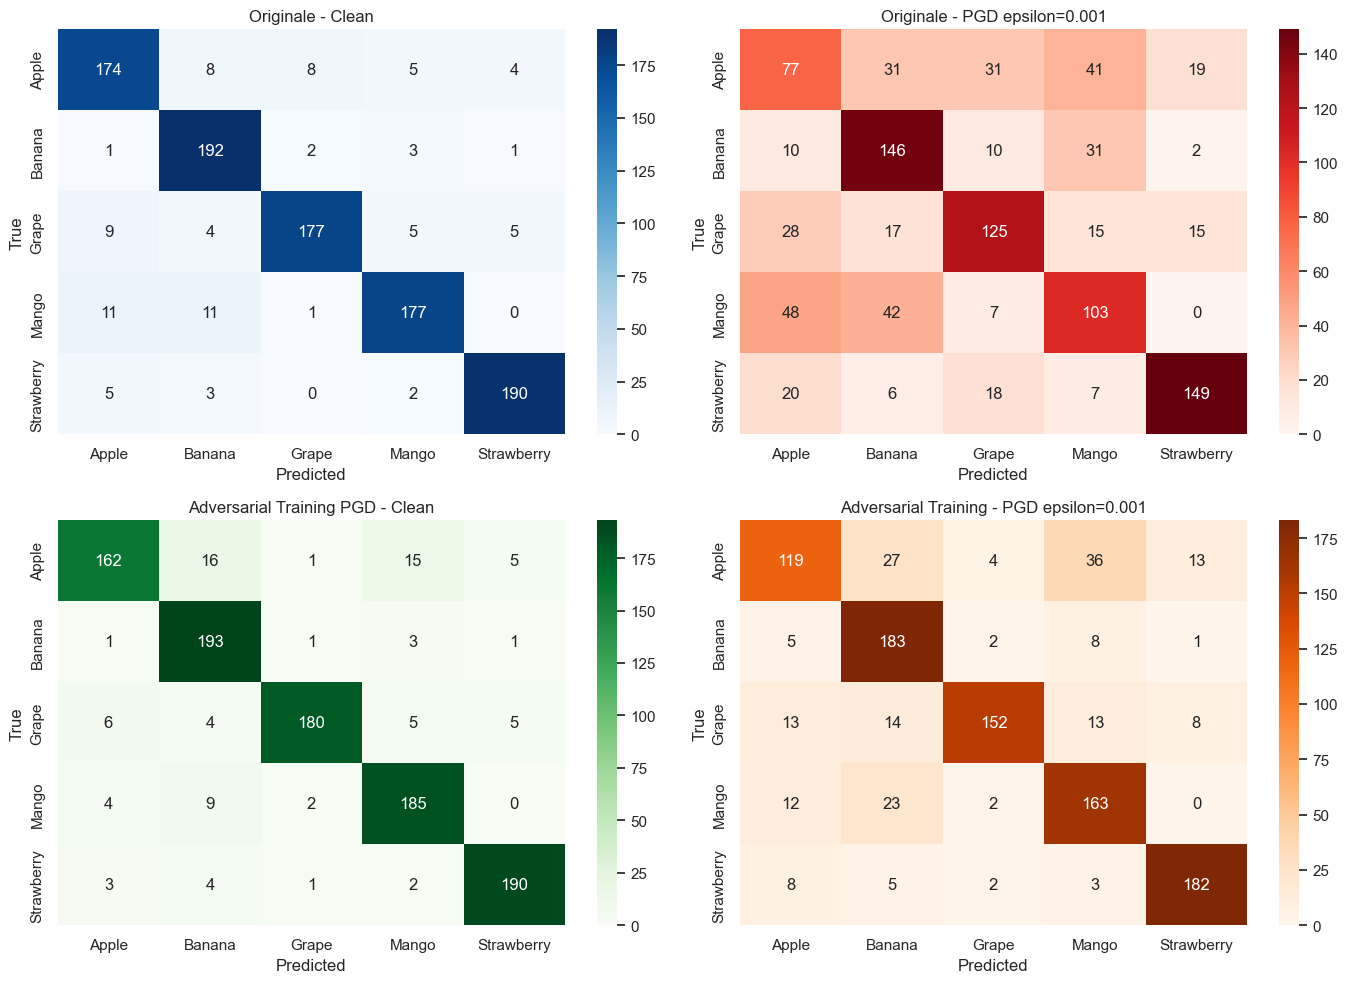

In [23]:
epsilon_test = 0.001
alpha_test = 0.00025
num_steps_test = 10

pgd_model.load_state_dict(torch.load(model_save_path))

model.eval()
pgd_model.eval()

correct_orig_clean = 0
correct_orig_adv = 0
attack_success_orig = 0

correct_pgd_clean = 0
correct_pgd_adv = 0
attack_success_pgd = 0

total = 0

all_labels = []
preds_orig_clean_all = []
preds_orig_adv_all = []
preds_pgd_clean_all = []
preds_pgd_adv_all = []

for images, labels in tqdm(test_loader, desc=f"Confronto PGD epsilon={epsilon_test}"):
    images = images.to(device)
    labels = labels.to(device)

    # modello originale su immagini pulite
    with torch.no_grad():
        outputs_orig_clean = model(NORMALIZE(images))
        preds_orig_clean = torch.argmax(outputs_orig_clean, dim=1)

    # modello originale su immagini adversarial
    adv_images_orig, perturbation = pgd_attack(
        model,
        images.clone().detach(),
        labels,
        epsilon_test,
        alpha_test,
        num_steps_test,
        loss_fn
    )

    with torch.no_grad():
        outputs_orig_adv = model(NORMALIZE(adv_images_orig))
        preds_orig_adv = torch.argmax(outputs_orig_adv, dim=1)

    # modello adversarial trained su immagini pulite
    with torch.no_grad():
        outputs_pgd_clean = pgd_model(NORMALIZE(images))
        preds_pgd_clean = torch.argmax(outputs_pgd_clean, dim=1)

    # modello adversarial trained su immagini adversarial
    adv_images_pgd, _ = pgd_attack(
        pgd_model,
        images.clone().detach(),
        labels,
        epsilon_test,
        alpha_test,
        num_steps_test,
        loss_fn
    )

    with torch.no_grad():
        outputs_pgd_adv = pgd_model(NORMALIZE(adv_images_pgd))
        preds_pgd_adv = torch.argmax(outputs_pgd_adv, dim=1)

    correct_orig_clean += (preds_orig_clean == labels).sum().item()
    correct_orig_adv += (preds_orig_adv == labels).sum().item()
    attack_success_orig += ((preds_orig_clean == labels) & (preds_orig_adv != labels)).sum().item()

    correct_pgd_clean += (preds_pgd_clean == labels).sum().item()
    correct_pgd_adv += (preds_pgd_adv == labels).sum().item()
    attack_success_pgd += ((preds_pgd_clean == labels) & (preds_pgd_adv != labels)).sum().item()

    total += labels.size(0)

    # per tutti i batch
    all_labels.extend(labels.cpu().numpy())
    preds_orig_clean_all.extend(preds_orig_clean.cpu().numpy())
    preds_orig_adv_all.extend(preds_orig_adv.cpu().numpy())
    preds_pgd_clean_all.extend(preds_pgd_clean.cpu().numpy())
    preds_pgd_adv_all.extend(preds_pgd_adv.cpu().numpy())

# metriche
acc_orig_clean = correct_orig_clean / total
acc_orig_adv = correct_orig_adv / total
drop_orig = acc_orig_clean - acc_orig_adv
asr_orig = attack_success_orig / correct_orig_clean

acc_pgd_clean = correct_pgd_clean / total
acc_pgd_adv = correct_pgd_adv / total
drop_pgd = acc_pgd_clean - acc_pgd_adv
asr_pgd = attack_success_pgd / correct_pgd_clean

comparison_df = pd.DataFrame({
    'model': ['Originale', 'Adversarial Training PGD'],
    'epsilon_attack': [epsilon_test, epsilon_test],
    'accuracy_clean': [acc_orig_clean, acc_pgd_clean],
    'accuracy_adversarial': [acc_orig_adv, acc_pgd_adv],
    'accuracy_drop': [drop_orig, drop_pgd],
    'asr': [asr_orig, asr_pgd],
})

print(comparison_df.to_string(index=False))

comparison_df.to_csv(results_path / "PGD_original_vs_adv.csv", index=False)

# plot heatmap
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cm_orig_clean = confusion_matrix(all_labels, preds_orig_clean_all)
cm_orig_adv = confusion_matrix(all_labels, preds_orig_adv_all)
cm_pgd_clean = confusion_matrix(all_labels, preds_pgd_clean_all)
cm_pgd_adv = confusion_matrix(all_labels, preds_pgd_adv_all)

sns.heatmap(cm_orig_clean, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0, 0])
axes[0, 0].set_title('Originale - Clean')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('True')

sns.heatmap(cm_orig_adv, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0, 1])
axes[0, 1].set_title(f'Originale - PGD epsilon={epsilon_test}')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('True')

sns.heatmap(cm_pgd_clean, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1, 0])
axes[1, 0].set_title('Adversarial Training PGD - Clean')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('True')

sns.heatmap(cm_pgd_adv, annot=True, fmt='d', cmap='Oranges',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1, 1])
axes[1, 1].set_title(f'Adversarial Training - PGD epsilon={epsilon_test}')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('True')

plt.tight_layout()
plt.savefig(results_path / "PGD_original_vs_adv.png", dpi=120, bbox_inches='tight')
plt.show()